# Experiment: MPC Visualization

Notebook to visualize the rolling-horizon execution of the inventory-control MPC.

This notebook reuses:
- `inventory_mpc.controller.Controller`
- `inventory_mpc.scenarios.ScenarioGenerator`
- `inventory_mpc.metrics.KPITracker` (Step 6)


In [ ]:
# %matplotlib inline

import sys
from pathlib import Path
from random import Random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

# Make sure that imports are made properly
cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from pyomo.environ import SolverFactory

from model.demand import DemandDistribution
from model.metrics import KPITracker
from control_mpc.mpc_policy import MPCPolicy
from control_mpc.scenarios import ScenarioGenerator
from model.state import SKUState

plt.style.use("default")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:.0f}")


def display_no_decimals(df: pd.DataFrame) -> None:
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        out[col] = np.round(out[col]).astype("Int64")
    display(out)


In [ ]:
# Configuration
sku_count = 1
days = 30

H = 5
Ns = 12
L_max = 3

preferred_solver = "highs"
solver_fallback = ["cbc", "gurobi"]

random_seed = 2025
sku_to_view = 0

demand_distribution = {
    "kind": "normal_clipped",
    "mean": 8.0,
    "std": 3.0,
    "low": 0.0,
    "high": 20.0,
}

demand_model = DemandDistribution(demand_distribution)
d_low, d_high = demand_model.bounds()

params = {
    "H": H,
    "Ns": Ns,
    "Lmax": L_max,
    "K_fix": 8.0,
    "v": 1.0,
    "h": 0.15,
    "p": 6.0,
    "lambda": 0.5,
    "q_min": 0.0,
    "q_max": 40.0,
    "I_target": 12.0,
    "scenario_demand_low": d_low,
    "scenario_demand_high": d_high,
    "scenario_lead_time_weights": [0.5, 0.35, 0.15],
}

def resolve_solver(preferred: str, fallback: list[str]) -> str:
    candidates = [preferred] + [s for s in fallback if s != preferred]
    for name in candidates:
        try:
            if SolverFactory(name).available(False):
                return name
        except Exception:
            pass
    raise RuntimeError(f"No solver available from: {candidates}")

solver_name = resolve_solver(preferred_solver, solver_fallback)
print(f"solver selected: {solver_name}")
print(f"demand_distribution: {demand_distribution}")


solver selected: highs
demand_distribution: {'kind': 'normal_clipped', 'mean': 8.0, 'std': 3.0, 'low': 0.0, 'high': 20.0}


## Demand and Lead-Time Distributions

They are sampled with `ScenarioGenerator` using the same parameters.


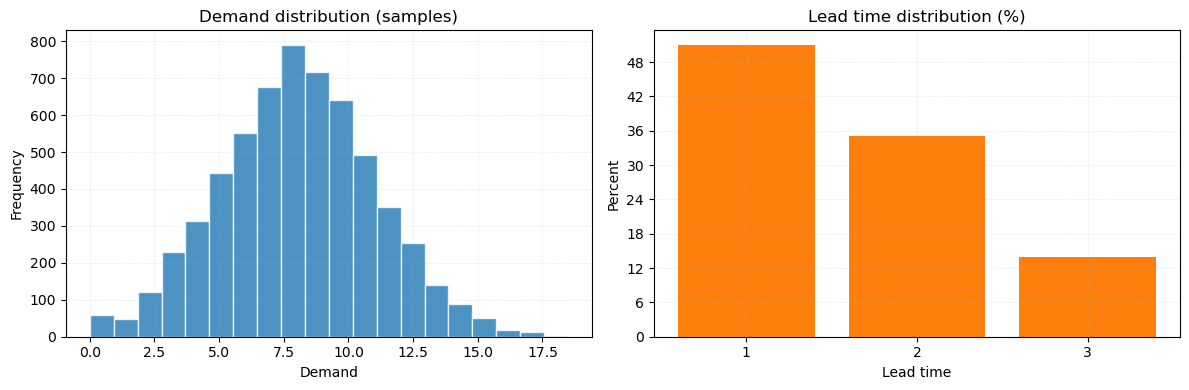

,variable,mean,variance
0,demand,8,9
1,lead_time,2,1


In [22]:
dist_gen = ScenarioGenerator(
    H=days,
    Ns=max(200, Ns),
    Lmax=L_max,
    demand_low=params["scenario_demand_low"],
    demand_high=params["scenario_demand_high"],
    lead_time_weights=params["scenario_lead_time_weights"],
    seed=random_seed,
    demand_generator=demand_model.sample,
)
dist_scen = dist_gen.generate()

demand_samples = np.array(dist_scen["D"]).reshape(-1)
lead_samples = np.array(dist_scen["L"]).reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(demand_samples, bins=20, alpha=0.8, color="#1f77b4", edgecolor="white")
axes[0].set_title("Demand distribution (samples)")
axes[0].set_xlabel("Demand")
axes[0].set_ylabel("Frequency")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))

lead_counts = pd.Series(lead_samples).value_counts().sort_index()
lead_pct = (100 * lead_counts / lead_counts.sum()).round().astype(int)
axes[1].bar(lead_pct.index.astype(int), lead_pct.values, color="#ff7f0e")
axes[1].set_xticks(range(1, L_max + 1))
axes[1].set_title("Lead time distribution (%)")
axes[1].set_xlabel("Lead time")
axes[1].set_ylabel("Percent")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))

for ax in axes:
    ax.grid(alpha=0.2, linestyle="--", linewidth=0.6)

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(
    {
        "mean": [demand_samples.mean(), lead_samples.mean()],
        "variance": [demand_samples.var(), lead_samples.var()],
    },
    index=["demand", "lead_time"],
)
stats_view = stats_df.reset_index().rename(columns={"index": "variable"})
display_no_decimals(stats_view)


## Rolling-Horizon Simulation and Daily Table

The simulation runs MPC day by day (receding horizon), not as an open-loop plan.


In [23]:
def run_simulation(sku_count: int, days: int, params: dict, solver_name: str, seed: int):
    states = [
        SKUState(on_hand=12.0, pipeline=[2.0, 0.0, 0.0])
        for _ in range(sku_count)
    ]
    policies = [
        MPCPolicy(
            params=params,
            solver_name=solver_name,
            scenario_seed=101 + i,
            demand_generator=demand_model.sample,
        )
        for i in range(sku_count)
    ]

    env_rng = Random(seed + sku_count)
    lead_time_weights = params["scenario_lead_time_weights"]
    lead_time_values = list(range(1, int(params["Lmax"]) + 1))

    tracker = KPITracker(
        K_fix=params["K_fix"],
        v=params["v"],
        h=params["h"],
        p=params["p"],
    )

    def format_pipeline(values):
        return str([int(round(v)) for v in values])

    rows = []
    for t in range(days):
        demands = [
            demand_model.sample(t, sku, env_rng)
            for sku in range(sku_count)
        ]
        lead_times = [
            env_rng.choices(lead_time_values, weights=lead_time_weights, k=1)[0]
            for _ in range(sku_count)
        ]

        starts = [
            {
                "I_start": float(st.on_hand),
                "pipeline_start": list(st.pipeline),
            }
            for st in states
        ]

        for sku in range(sku_count):
            q = float(policies[sku].compute_action(states[sku]))
            tr = states[sku].step(demand=float(demands[sku]), q=q, L=int(lead_times[sku]))

            L = int(lead_times[sku]) if q > 0.0 else np.nan
            arrival_day = int(t + L) if q > 0.0 else np.nan

            tracker.record_step(
                q=q,
                demand=float(demands[sku]),
                sales=float(tr["sales"]),
                lost_sales=float(tr["lost_sales"]),
                inventory=float(tr["I_next"]),
            )

            row = {
                "sku": sku,
                "t": t,
                "I_start": starts[sku]["I_start"],
                "pipeline_start": format_pipeline(starts[sku]["pipeline_start"]),
                "R": float(tr["received"]),
                "D": float(demands[sku]),
                "sales": float(tr["sales"]),
                "lost_sales": float(tr["lost_sales"]),
                "q": q,
                "L": L,
                "arrival_day": arrival_day,
                "I_end": float(tr["I_next"]),
                "pipeline_end": format_pipeline(list(states[sku].pipeline)),
            }

            for i, value in enumerate(starts[sku]["pipeline_start"], start=1):
                row[f"P{i}_start"] = float(value)
            for i, value in enumerate(states[sku].pipeline, start=1):
                row[f"P{i}_end"] = float(value)

            rows.append(row)

    df = pd.DataFrame(rows).sort_values(["sku", "t"]).reset_index(drop=True)
    return df, tracker.summary()


df, kpi_summary = run_simulation(
    sku_count=sku_count,
    days=days,
    params=params,
    solver_name=solver_name,
    seed=random_seed,
)

required_cols = [
    "t", "I_start", "pipeline_start", "R", "D", "sales", "lost_sales", "q", "L", "arrival_day", "I_end"
]

df_sku = df[df["sku"] == sku_to_view].copy()
display_no_decimals(df_sku[required_cols])


,t,I_start,pipeline_start,R,D,sales,lost_sales,q,L,arrival_day,I_end
0,0,12,"[2, 0, 0]",2,11,11,0,31,2,2,3
1,1,3,"[0, 31, 0]",0,10,3,7,0,<NA>,<NA>,0
2,2,0,"[31, 0, 0]",31,10,10,0,17,2,4,21
3,3,21,"[0, 17, 0]",0,9,9,0,0,<NA>,<NA>,12
4,4,12,"[17, 0, 0]",17,9,9,0,0,<NA>,<NA>,20
5,5,20,"[0, 0, 0]",0,4,4,0,23,2,7,16
6,6,16,"[0, 23, 0]",0,8,8,0,0,<NA>,<NA>,7
7,7,7,"[23, 0, 0]",23,4,4,0,0,<NA>,<NA>,26
8,8,26,"[0, 0, 0]",0,12,12,0,19,1,9,14
9,9,14,"[19, 0, 0]",19,12,12,0,0,<NA>,<NA>,21


## Narrative View by Day

`explain_day` summarizes the events of a specific day for one SKU.


In [24]:
def explain_day(df_sku: pd.DataFrame, t0: int) -> None:
    row = df_sku[df_sku["t"] == t0]
    if row.empty:
        print(f"No data for day {t0}")
        return
    r = row.iloc[0]
    print(f"Day {int(r['t'])}")
    print(f"  I_start: {int(round(r['I_start']))}")
    print(f"  Pipeline start: {r['pipeline_start']}")
    print(f"  Arrivals today (R): {int(round(r['R']))}")
    print(f"  Demand (D): {int(round(r['D']))}")
    print(f"  Sales: {int(round(r['sales']))} | Lost sales: {int(round(r['lost_sales']))}")
    print(f"  MPC order q: {int(round(r['q']))}")
    if pd.notna(r["L"]):
        print(f"  Lead time sampled: {int(r['L'])} -> arrival_day={int(r['arrival_day'])}")
    else:
        print("  Lead time sampled: NaN (no order)")
    print(f"  Pipeline end: {r['pipeline_end']}")
    print(f"  I_end: {int(round(r['I_end']))}")


for t0 in [0, min(5, days - 1), days - 1]:
    explain_day(df_sku, t0)
    print("-" * 60)


Day 0
  I_start: 12
  Pipeline start: [2, 0, 0]
  Arrivals today (R): 2
  Demand (D): 11
  Sales: 11 | Lost sales: 0
  MPC order q: 31
  Lead time sampled: 2 -> arrival_day=2
  Pipeline end: [0, 31, 0]
  I_end: 3
------------------------------------------------------------
Day 5
  I_start: 20
  Pipeline start: [0, 0, 0]
  Arrivals today (R): 0
  Demand (D): 4
  Sales: 4 | Lost sales: 0
  MPC order q: 23
  Lead time sampled: 2 -> arrival_day=7
  Pipeline end: [0, 23, 0]
  I_end: 16
------------------------------------------------------------
Day 29
  I_start: 29
  Pipeline start: [0, 0, 0]
  Arrivals today (R): 0
  Demand (D): 10
  Sales: 10 | Lost sales: 0
  MPC order q: 0
  Lead time sampled: NaN (no order)
  Pipeline end: [0, 0, 0]
  I_end: 19
------------------------------------------------------------


## Time Series (Selected SKU)


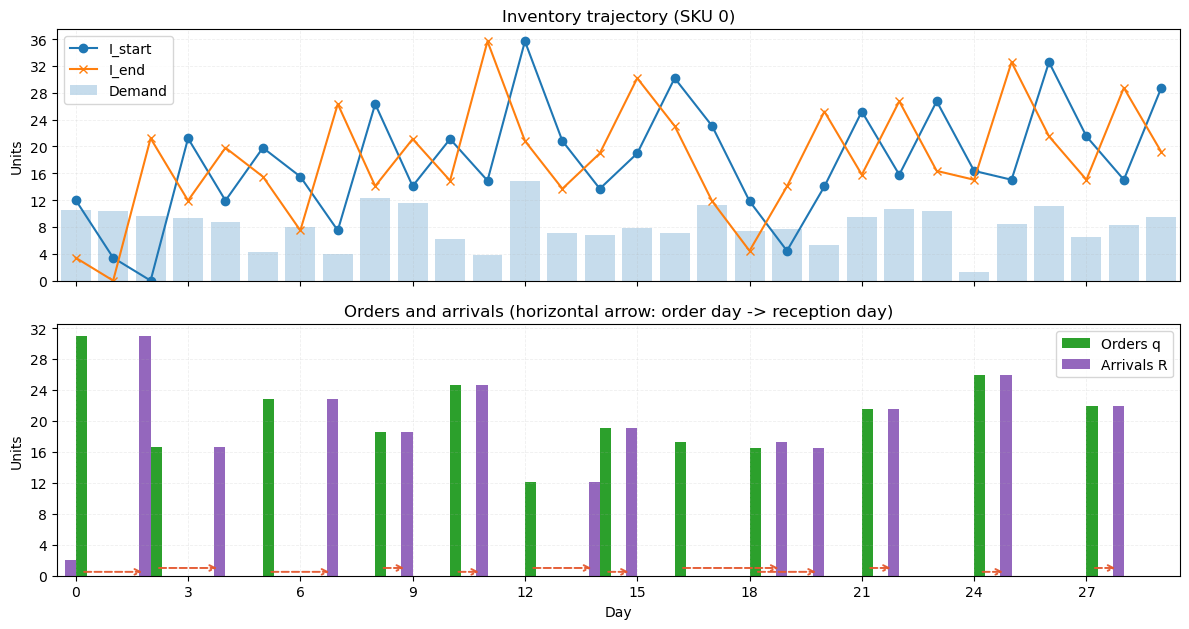

In [ ]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 6.4),  # ~20% menos altura total que (12, 8)
    sharex=True,
    gridspec_kw={"height_ratios": [1, 1]},  # ambos subplots con la misma altura
)

# Inventory time series
axes[0].plot(df_sku["t"], df_sku["I_start"], marker="o", label="I_start")
axes[0].plot(df_sku["t"], df_sku["I_end"], marker="x", label="I_end")
axes[0].bar(df_sku["t"], df_sku["D"], alpha=0.25, label="Demand")
axes[0].set_ylabel("Units")
axes[0].set_title(f"Inventory trajectory (SKU {sku_to_view})")
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[0].grid(alpha=0.2, linestyle="--", linewidth=0.6)
axes[0].legend(loc="upper left")  # leyenda arriba a la izquierda

# Orders + arrivals in same panel (bars offset), with horizontal arrows order_day -> arrival_day
x = df_sku["t"].to_numpy()
order_shift = 0.15
arrival_shift = -0.15
width = 0.3

axes[1].bar(x + order_shift, df_sku["q"], width=width, color="#2ca02c", label="Orders q")
axes[1].bar(x + arrival_shift, df_sku["R"], width=width, color="#9467bd", label="Arrivals R")

order_rows = df_sku[pd.notna(df_sku["arrival_day"]) & (df_sku["q"] > 0)].copy()

# The postion of the arrows will alternate between two heights to avoid overlap with previous orders
arrow_heights = [0.5, 1.0]
for i, (_, r) in enumerate(order_rows.iterrows()):
    x0 = float(r["t"]) + order_shift
    x1 = float(r["arrival_day"]) + arrival_shift
    y_arrow = arrow_heights[i % len(arrow_heights)]

    axes[1].annotate(
        "",
        xy=(x1, y_arrow),
        xytext=(x0, y_arrow),
        arrowprops=dict(
            arrowstyle="->",
            lw=1.4,
            linestyle="--",  # dashed
            color="#e4572e",
            alpha=0.95,
        ),
        zorder=6,
        clip_on=False,
    )

if len(order_rows) > 0:
    max_arrival = int(np.nanmax(order_rows["arrival_day"].to_numpy()))
else:
    max_arrival = int(df_sku["t"].max())

axes[1].set_xlim(-0.5, max(int(df_sku["t"].max()), max_arrival) + 0.5)

axes[1].set_ylabel("Units")
axes[1].set_xlabel("Day")
axes[1].set_title("Orders and arrivals (horizontal arrow: order day -> reception day)")
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].grid(alpha=0.2, linestyle="--", linewidth=0.6)
axes[1].legend(loc="upper right")  # leyenda arriba a la izquierda

plt.tight_layout()
plt.show()

## KPIs (Step 6 Metrics)

Per-SKU and aggregated KPIs (including total cost, fill rate, average inventory, and stockout count).


In [26]:
def kpi_per_sku(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    rows = []
    for sku, g in df.groupby("sku"):
        total_demand = float(g["D"].sum())
        total_sales = float(g["sales"].sum())
        total_lost = float(g["lost_sales"].sum())
        total_cost = float(
            (params["K_fix"] * (g["q"] > 0).sum())
            + (params["v"] * g["q"]).sum()
            + (params["h"] * g["I_end"]).sum()
            + (params["p"] * g["lost_sales"]).sum()
        )
        fill_rate = (total_sales / total_demand) if total_demand > 0 else 1.0
        rows.append(
            {
                "sku": int(sku),
                "total_cost": total_cost,
                "total_lost_sales": total_lost,
                "fill_rate_pct": 100 * fill_rate,
                "avg_inventory": float(g["I_end"].mean()),
                "order_events": int((g["q"] > 0).sum()),
                "stockout_count": int((g["lost_sales"] > 0).sum()),
            }
        )
    out = pd.DataFrame(rows).sort_values("sku").reset_index(drop=True)
    return out


kpi_sku = kpi_per_sku(df, params)

total_demand = float(df["D"].sum())
total_sales = float(df["sales"].sum())
kpi_agg = pd.DataFrame(
    [
        {
            "total_cost": float(kpi_sku["total_cost"].sum()),
            "total_lost_sales": float(kpi_sku["total_lost_sales"].sum()),
            "fill_rate_weighted_pct": 100 * ((total_sales / total_demand) if total_demand > 0 else 1.0),
            "avg_inventory": float(df["I_end"].mean()),
            "order_events": int(kpi_sku["order_events"].sum()),
            "stockout_count": int(kpi_sku["stockout_count"].sum()),
        }
    ]
)

print("KPI summary (tracker from Step 6):")
tracker_df = pd.DataFrame([kpi_summary]).rename(columns={"fill_rate": "fill_rate_pct"})
tracker_df["fill_rate_pct"] = 100 * tracker_df["fill_rate_pct"]
display_no_decimals(tracker_df)

print("KPIs per SKU:")
display_no_decimals(kpi_sku)

print("Aggregated KPIs:")
display_no_decimals(kpi_agg)


KPI summary (tracker from Step 6):


,total_cost,fill_rate_pct,avg_inventory,stockout_count
0,468,97,18,1


KPIs per SKU:


,sku,total_cost,total_lost_sales,fill_rate_pct,avg_inventory,order_events,stockout_count
0,0,468,7,97,18,12,1


Aggregated KPIs:


,total_cost,total_lost_sales,fill_rate_weighted_pct,avg_inventory,order_events,stockout_count
0,468,7,97,18,12,1
